In [1]:
# ============================================================
#  CONFIG — the only cell you edit for a new dataset
# ============================================================
import os

# --- 1. INPUT: where the raw per-temperature data lives ---
BASE = '/nfs/chess/id4baux/2026-1/wilson-4797-a/nxrefine/HfV2/HfV2_g3_s2/'
MATERIAL = 'HfV2'                        # used to name output files/folders and find axis files

# --- 2. STACKING options ---
STEP = 4                                 # downsampling: every STEP-th point per axis (1 = full res)

# --- 3. OUTPUT: where stacked file and sweep results go ---
OUTPUT_ROOT = '/nfs/chess/id4baux/summer_project/qm2_XTEC'
STACKED_FILE = f'{OUTPUT_ROOT}/{MATERIAL}_stacked.nxs'
PARENT_DIR   = f'{OUTPUT_ROOT}/{MATERIAL}'          # sweep output folder
HOME_LINK    = f'{os.path.expanduser("~")}/{MATERIAL}'  # clickable shortcut in file browser

# --- 4. SLICE: region of reciprocal space to analyze ---
# Order is [T, Ql, Qk, Qh]. Used by BOTH the notebook load AND the sweep,
# so they always match. ':' means all temperatures.
QL_LO, QL_HI = -1.5, 1.5      # thin slab in L
QK_LO, QK_HI = -5.0, 5.0
QH_LO, QH_HI = -5.0, 5.0
SLICES = f":,{QL_LO}:{QL_HI},{QK_LO}:{QK_HI},{QH_LO}:{QH_HI}"   # string form for the sweep CLI

# --- 5. SWEEP settings ---
XTEC      = "/nfs/chess/sw/qm2_XTEC/xtec_gpu_env/bin/xtec-gpu"
RESCALES  = ["mean", "z-score"]
MIN_NC, MAX_NC = 2, 8
MODES     = "d"
INITS     = "kmeans++"
DEVICE    = "cpu"

# --- 6. Data structure inside the raw files (rarely changes) ---
VOL_PATH  = 'entry/data/v'               # where the intensity volume lives in transform.nxs
AXIS_GRP  = 'entry/transform'            # where Qh/Qk/Ql live in the per-T .nxs file
MEMORY_MB = 8000                         # nexus memory limit for loading

print("Config loaded for:", MATERIAL)
print("  input :", BASE)
print("  stacked:", STACKED_FILE)
print("  slice :", SLICES)

Config loaded for: HfV2
  input : /nfs/chess/id4baux/2026-1/wilson-4797-a/nxrefine/HfV2/HfV2_g3_s2/
  stacked: /nfs/chess/id4baux/summer_project/qm2_XTEC/HfV2_stacked.nxs
  slice : :,-1.5:1.5,-5.0:5.0,-5.0:5.0


In [2]:
#Step 1: Point at data and discover temperatures
import h5py, numpy as np, os, time, re

base = BASE
step = STEP

# Discover temperature folders, keep only those with a transform.nxs
entries = os.listdir(base)
all_temps = sorted(
    int(e) for e in entries
    if os.path.isdir(os.path.join(base, e)) and e.isdigit()
)
temps = [T for T in all_temps
         if os.path.exists(os.path.join(base, str(T), 'transform.nxs'))]
skipped = [T for T in all_temps if T not in temps]

print(f"base: {base}")
print(f"found {len(all_temps)} temperature folders total")
if skipped:
    print(f"SKIPPING {len(skipped)} without transform.nxs: {skipped}")
print(f"using {len(temps)} temperatures:")
print(temps)

base: /nfs/chess/id4baux/2026-1/wilson-4797-a/nxrefine/HfV2/HfV2_g3_s2/
found 21 temperature folders total
SKIPPING 2 without transform.nxs: [0, 90]
using 19 temperatures:
[13, 14, 20, 30, 40, 50, 60, 69, 70, 80, 89, 100, 110, 120, 130, 150, 200, 240, 300]


In [3]:
#Step 2: Read axes + size
step = STEP

# Axes live in the TOP-LEVEL per-temperature file, under AXIS_GRP
axis_file = os.path.join(base, f'{MATERIAL}_{temps[0]}.nxs')
with h5py.File(axis_file, 'r') as f:
    Qh = np.array(f[f'{AXIS_GRP}/Qh'])[::step]
    Qk = np.array(f[f'{AXIS_GRP}/Qk'])[::step]
    Ql = np.array(f[f'{AXIS_GRP}/Ql'])[::step]

# Volume lives in the FOLDER's transform.nxs, under VOL_PATH
vol_file = os.path.join(base, str(temps[0]), 'transform.nxs')
with h5py.File(vol_file, 'r') as f:
    assert VOL_PATH in f, "no volume at VOL_PATH — stop and check"
    full_shape = f[VOL_PATH].shape

nT = len(temps)
shape = (nT, len(Ql), len(Qk), len(Qh))

print(f"axes from : {os.path.basename(axis_file)}  ({AXIS_GRP}/Qh,Qk,Ql)")
print(f"volume from: {temps[0]}/transform.nxs  shape {full_shape}")
print(f"downsample step = {step}")
print(f"stacked shape will be: {shape}")
print(f"approx size: {np.prod(shape) * 4 / 1e9:.2f} GB")

axes from : HfV2_13.nxs  (entry/transform/Qh,Qk,Ql)
volume from: 13/transform.nxs  shape (1601, 1601, 1601)
downsample step = 4
stacked shape will be: (19, 401, 401, 401)
approx size: 4.90 GB


In [4]:
#Step 3: Stacking
out = STACKED_FILE
os.makedirs(os.path.dirname(out), exist_ok=True)

start = time.time()
with h5py.File(out, 'w') as fout:
    entry = fout.create_group('entry')
    data = entry.create_group('data')
    entry.attrs['NX_class'] = 'NXentry'
    data.attrs['NX_class'] = 'NXdata'
    data.attrs['signal'] = 'v'
    data.attrs['axes'] = ['T', 'Ql', 'Qk', 'Qh']

    v = data.create_dataset('v', shape=shape, dtype='float32')
    data.create_dataset('T',  data=np.array(temps, dtype=np.float32))
    data.create_dataset('Ql', data=Ql.astype(np.float32))
    data.create_dataset('Qk', data=Qk.astype(np.float32))
    data.create_dataset('Qh', data=Qh.astype(np.float32))

    for i, T in enumerate(temps):
        p = os.path.join(base, str(T), 'transform.nxs')
        with h5py.File(p, 'r') as f:
            vol = f[VOL_PATH][::step, ::step, ::step].astype(np.float32)
        v[i, :, :, :] = vol
        del vol
        print(f"  [{i+1}/{nT}] T={T}K  ({time.time()-start:.0f}s)", flush=True)

print(f"\nSAVED: {out} | shape {shape} | total {time.time()-start:.0f}s")

  [1/19] T=13K  (103s)
  [2/19] T=14K  (204s)
  [3/19] T=20K  (305s)
  [4/19] T=30K  (405s)
  [5/19] T=40K  (512s)
  [6/19] T=50K  (614s)
  [7/19] T=60K  (716s)
  [8/19] T=69K  (819s)
  [9/19] T=70K  (918s)
  [10/19] T=80K  (1021s)
  [11/19] T=89K  (1122s)
  [12/19] T=100K  (1222s)
  [13/19] T=110K  (1323s)
  [14/19] T=120K  (1427s)
  [15/19] T=130K  (1526s)
  [16/19] T=150K  (1627s)
  [17/19] T=200K  (1730s)
  [18/19] T=240K  (1832s)
  [19/19] T=300K  (1932s)

SAVED: /nfs/chess/id4baux/summer_project/qm2_XTEC/HfV2_stacked.nxs | shape (19, 401, 401, 401) | total 1932s


In [5]:
# Step 4: Verification
with h5py.File(out, 'r') as f:
    print("signal:", f['entry/data'].attrs['signal'])
    print("axes:  ", list(f['entry/data'].attrs['axes']))
    print("v shape:", f['entry/data/v'].shape)
    print("T values:", np.array(f['entry/data/T']))
    sample = f['entry/data/v'][0]
    print(f"T[0] slice: min={sample.min():.2f} max={sample.max():.2f} mean={sample.mean():.3f}")
print(f"\nReady if v shape is ({nT}, Ql, Qk, Qh), T matches temps, and the slice isn't all zeros.")

signal: v
axes:   ['T', 'Ql', 'Qk', 'Qh']
v shape: (19, 401, 401, 401)
T values: [ 13.  14.  20.  30.  40.  50.  60.  69.  70.  80.  89. 100. 110. 120.
 130. 150. 200. 240. 300.]
T[0] slice: min=0.00 max=126842.99 mean=2.268

Ready if v shape is (19, Ql, Qk, Qh), T matches temps, and the slice isn't all zeros.


In [7]:
# Step 5.1: Import statements

import glob
import os
import time

import matplotlib.pyplot as plt
import numpy as np

from nexusformat.nexus import (nxgetmemory, nxload, nxsetmemory, NXdata,
                               NXentry, NXfield)

from xtec.Preprocessing import Mask_Zeros              # remove zero-intensity points
from xtec.Preprocessing import Threshold_Background    # threshold background intensity
from xtec.GMM import GMM                               # GMM clustering (for later)

In [8]:
# Step 5.2: Peek at Q ranges to find slice
nxsetmemory(MEMORY_MB)

data_filename = STACKED_FILE
data_file = nxload(data_filename, 'r')

Qh = data_file['entry/data/Qh'].nxvalue
Qk = data_file['entry/data/Qk'].nxvalue
Ql = data_file['entry/data/Ql'].nxvalue
print("Qh:", round(float(Qh[0]),1), "to", round(float(Qh[-1]),1))
print("Qk:", round(float(Qk[0]),1), "to", round(float(Qk[-1]),1))
print("Ql:", round(float(Ql[0]),1), "to", round(float(Ql[-1]),1))

Qh: -8.0 to 8.0
Qk: -8.0 to 8.0
Ql: -8.0 to 8.0


In [9]:
# Step 5.3: load region (uses SLICE from config, so it matches the sweep)
data = data_file['entry/data'][:, QL_LO:QL_HI, QK_LO:QK_HI, QH_LO:QH_HI]

I  = data.nxsignal.nxvalue
Qh = data['Qh'].nxvalue
Qk = data['Qk'].nxvalue
Ql = data['Ql'].nxvalue
Temp = data['T'].nxvalue

print("I:", I.shape, " Temp:", Temp.shape)
print(f"kept Q-range: Ql [{QL_LO},{QL_HI}], Qk [{QK_LO},{QK_HI}], Qh [{QH_LO},{QH_HI}]")

I: (19, 75, 251, 251)  Temp: (19,)
kept Q-range: Ql [-1.5,1.5], Qk [-5.0,5.0], Qh [-5.0,5.0]


In [10]:
# Step 6.1: Threshold background intensity
start_time = time.time()

masked    = Mask_Zeros(I)                    # removes zero-intensity points
threshold = Threshold_Background(masked)     # removes low-intensity background

print("Thresholding Run Time:", time.time() - start_time)

Thresholding Run Time: 1.0497565269470215


In [11]:
# Step 6.2: Store and check thresholding results
Data_thresh = threshold.data_thresholded     # shape=(num_temperatures, num_thresholded)
Data_ind    = threshold.ind_thresholded       # hkl indices of thresholded data

print('num of original data pixels   =', np.prod(I.shape[1:]))
print('num of thresholded data pixels =', Data_thresh.shape[1])

num of original data pixels   = 4725075
num of thresholded data pixels = 1670647


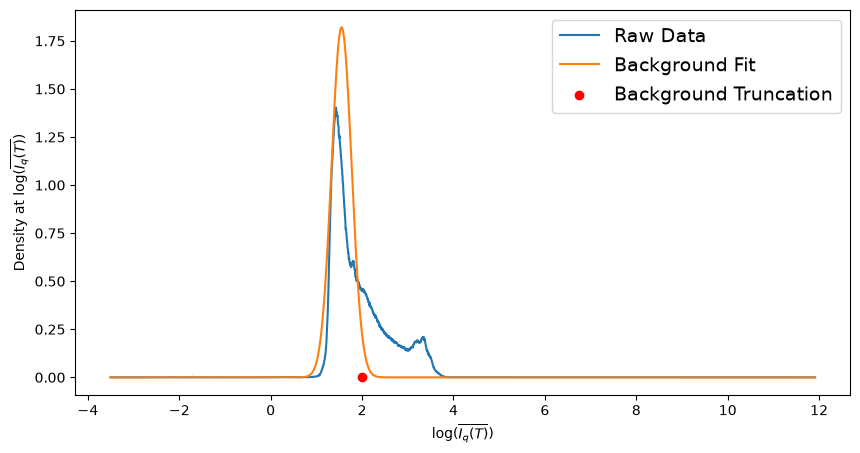

In [12]:
# Step 7: Distribution of log intensities with the estimated cutoff
figsize_ = (10, 5)
threshold.plot_cutoff(figsize_)

Text(0.5, 1.0, 'L=0.0')

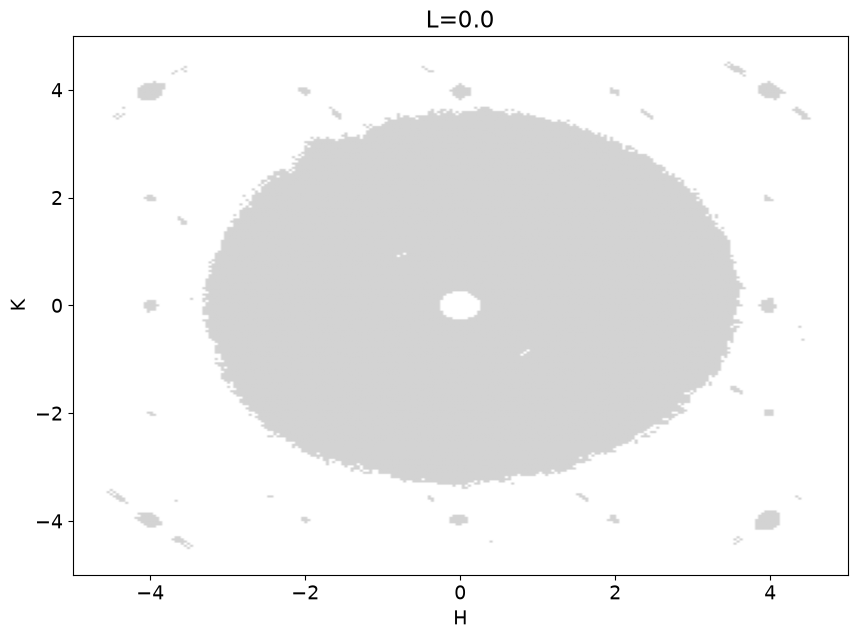

In [13]:
# Step 8: Q-space map
figsize_=(10,7) #changed aspect ratio

axis_ind = 0   # Select 0 for plotting l plane, 1 for k plane, 2 for h plane
slice_value = 0.0 # Value of the axis orthogonal to the selected plane
slice_ind = data.nxaxes[axis_ind+1].index(slice_value) # index of  the selected axis (h/k/l plane) to plot

threshold.plot_thresholding_2D_slice(figsize_, slice_ind, axis_ind)

# threshold.plot_thresholding_2D_slice(figsize_, slice_ind_, axis_) : plots the 2D image 
# with points whose intensity distribution is above the cutoff marked as grey. 
# if data is 3D, then set the slice ind and axis_ (default=None) to select the index of the 2D slice along axis_ =0,1 or 2.

ax = plt.gca()
ax.get_images()[0].set_extent((Qh[0], Qh[-1], Qk[0], Qk[-1])) 
ax.set_aspect('auto')          # let it fill the box naturally
plt.xlabel('H')
plt.ylabel('K')
plt.title(f'L={slice_value}')


In [14]:
# Step 9.1: Sweep + Judge (XTEC-d, rescales from config, k = MIN_NC..MAX_NC)
os.makedirs(PARENT_DIR, exist_ok=True)

for rescale in RESCALES:
    tag = rescale.replace("-", "")
    out_dir = f"{PARENT_DIR}/{MATERIAL}_sweep_{tag}_d"
    print(f"\n{'='*60}\nSWEEP: rescale={rescale}  ->  {out_dir}\n{'='*60}")

    !MPLBACKEND=agg "{XTEC}" full-sweep "{STACKED_FILE}" \
        -o "{out_dir}/" \
        --slices "{SLICES}" \
        --rescale {rescale} \
        --modes {MODES} \
        --min-nc {MIN_NC} --max-nc {MAX_NC} \
        --inits {INITS} \
        --device {DEVICE} \
        --stream off

print("\n\nAll sweeps done.")


SWEEP: rescale=mean  ->  /nfs/chess/id4baux/summer_project/qm2_XTEC/HfV2/HfV2_sweep_mean_d
[BIC XTEC-d] nc=2..8 | threshold=True | rescale=mean
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer.fit` stopped: `max_epochs=2` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) 

In [15]:
# Step 9.2: Make sweep results clickable in the file browser
src = PARENT_DIR
dst = HOME_LINK

if os.path.islink(dst) or os.path.exists(dst):
    os.remove(dst)

os.symlink(src, dst)
print("symlink created:", dst, "->", os.readlink(dst))
print("works:", os.path.exists(dst))

symlink created: /home/oyf2/HfV2 -> /nfs/chess/id4baux/summer_project/qm2_XTEC/HfV2
works: True
